In [58]:
import sys
from pathlib import Path

current_dir = Path.cwd()
notebooks_dir = current_dir if (current_dir / "etl.ipynb").exists() else current_dir / "notebooks"
if not (notebooks_dir / "etl.ipynb").exists():
    raise FileNotFoundError(f"Could not locate etl.ipynb from {current_dir}")

sys.path.insert(0, str(notebooks_dir))
import nbimporter

nbimporter.options["only_defs"] = False
etl = nbimporter.NotebookLoader([str(notebooks_dir)]).load_module("etl")

Extension: .csv
Extension: .mat
Extension: .mat
Extension: .mat
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .xlsx
Extension: .xlsx
Extension: .xlsx
Extension: .xlsx
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
dict_keys(['metadata_features', 'metadata', 'devices'])
dict_keys(['bia', 'exg', 'one_rm', 'ip', 'imu', 'cosmed', 'lactate', 'markers', 'lpt'])


In [68]:
participant_data = etl.load_data("V01")

Extension: .csv
Extension: .mat
Extension: .mat
Extension: .mat
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .xlsx
Extension: .xlsx
Extension: .xlsx
Extension: .xlsx
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv


In [69]:
participant_data["devices"].keys()

dict_keys(['bia', 'exg', 'one_rm', 'ip', 'imu', 'cosmed', 'lactate', 'markers', 'lpt'])

In [70]:
cosmed_v2 = participant_data["devices"]["cosmed"][2]
cosmed_v3 = participant_data["devices"]["cosmed"][3]
df_cosmed = cosmed_v2

In [71]:
from datetime import datetime

cosmedDate = df_cosmed.columns[4]
cosmedTime = df_cosmed.iloc[0, 4]

formatStartTime = "%H:%M:%S %p"
formatStartTimeStamp = "%d/%m/%Y %H:%M:%S %p"
cosmedDateString = cosmedDate + " " + cosmedTime
cosmedStartTimeStamp = datetime.strptime(cosmedDateString, formatStartTimeStamp)
cosmedStartTime = datetime.strptime(cosmedTime, formatStartTime)

In [72]:
df_cosmed = df_cosmed.drop(df_cosmed.columns[:9], axis='columns')
df_cosmed.head()

,t,Rf,VT,VE,IV,VO2,VCO2,RQ,O2exp,CO2exp,...,Ti/Ttot,VD/VT e,LogVE,t Rel,mark Speed,mark Distance,Phase time,BR,VT/Ti,PaCO2_e
0,s,1/min,L,L/min,mL,mL/min,mL/min,---,mL,mL,...,---,---,L/min,s,m/s,m,hh:mm:ss,%,L/s,mmHg
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00:00:04,14.29,0.281,4.014,928,126.02103,107.943582,0.86,48.4,9.4,...,0.74,0.05,0.604,0,0,0,00:00:00,97.7,0.09,33.86
3,00:00:07,21.58,1.044,22.532,456,276.915011,252.719393,0.91,201.8,14.8,...,0.33,0.57,1.353,3,0,0,00:00:03,87,1.15,28.21
4,00:00:09,23.53,0.76,17.882,589,635.58864,566.507084,0.89,126.2,29.6,...,0.47,0.14,1.252,2,0,0,00:00:05,89.7,0.63,36.36


In [73]:
# Extract first row
units = df_cosmed.iloc[0].astype(str)

# Combine column names with first row values
df_cosmed.columns = df_cosmed.columns + "[" + units + "]"

# Drop the first row since it's now part of the header, and second as it is empty
df_cosmed = df_cosmed.iloc[2:].reset_index(drop=True)

In [74]:
df_cosmed.head()

,t[s],Rf[1/min],VT[L],VE[L/min],IV[mL],VO2[mL/min],VCO2[mL/min],RQ[---],O2exp[mL],CO2exp[mL],...,Ti/Ttot[---],VD/VT e[---],LogVE[L/min],t Rel[s],mark Speed[m/s],mark Distance[m],Phase time[hh:mm:ss],BR[%],VT/Ti[L/s],PaCO2_e[mmHg]
0,00:00:04,14.29,0.281,4.014,928,126.02103,107.943582,0.86,48.4,9.4,...,0.74,0.05,0.604,0,0,0,00:00:00,97.7,0.09,33.86
1,00:00:07,21.58,1.044,22.532,456,276.915011,252.719393,0.91,201.8,14.8,...,0.33,0.57,1.353,3,0,0,00:00:03,87,1.15,28.21
2,00:00:09,23.53,0.76,17.882,589,635.58864,566.507084,0.89,126.2,29.6,...,0.47,0.14,1.252,2,0,0,00:00:05,89.7,0.63,36.36
3,00:00:11,27.15,0.4,10.86,286,410.734719,348.979046,0.85,65.3,15.8,...,0.41,0.1,1.036,2,0,0,00:00:07,93.7,0.44,39.06
4,00:00:14,23.35,0.532,12.42,495,499.911073,433.577679,0.87,85.4,22.8,...,0.45,0.08,1.094,3,0,0,00:00:10,92.8,0.46,38.87


In [97]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt

In [98]:
def time_to_seconds(value):
    if isinstance(value, dt.time):
        return (
            value.hour * 3600
            + value.minute * 60
            + value.second
            + value.microsecond / 1_000_000
        )

    return pd.to_timedelta(str(value)).total_seconds()

In [99]:
time_seconds = df_cosmed["t[s]"].map(time_to_seconds).to_numpy()
energy_rate = pd.to_numeric(df_cosmed["EEm[kcal/min]"],
                            errors="coerce",).to_numpy()

In [100]:
valid = np.isfinite(time_seconds) & np.isfinite(energy_rate)

# Total energy expenditure in kcal
total_energy_kcal = np.trapezoid(
    energy_rate[valid],
    time_seconds[valid] / 60,
)

total_energy_kcal

np.float64(169.94683333333336)

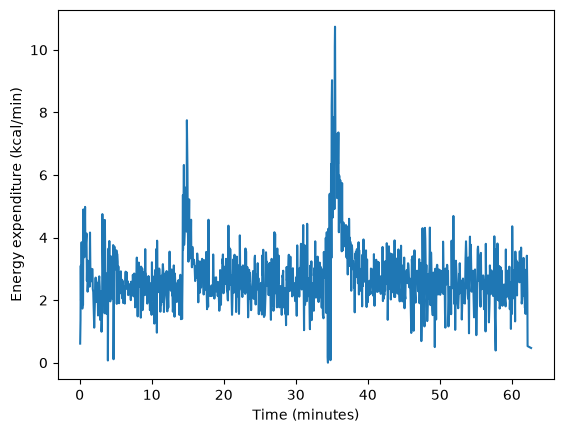

In [101]:
plt.plot(time_seconds / 60, energy_rate)
plt.xlabel("Time (minutes)")
plt.ylabel("Energy expenditure (kcal/min)")
plt.show()

In [108]:
import re

In [119]:
s = "PV01_V2_EXG_20260903152920.otb+"
match = re.search(r"(\d{6})(?=\D*$)", s)
print(match.group(1)) 

152920


In [106]:
participant_data["devices"]["exg"][2]

{'__header__': b'MATLAB 5.0 MAT-file, Platform: Win32NT, CREATED on: Wed, 16 Sep 2026 20:29:16 GMT',
 '__version__': '1.0',
 '__globals__': [],
 'SamplingFrequency': array([[2048.]]),
 'Data': array([[array([[ 0.4597982 , -0.03662109],
                [ 0.289917  , -0.02543131],
                [ 0.26194254, -0.02288818],
                ...,
                [ 0.41249594, -0.07273356],
                [ 0.43436685, -0.06561279],
                [ 0.46437582, -0.06917318]], shape=(7815177, 2), dtype=float32)]],
       dtype=object),
 'Time': array([[array([[0.00000000e+00],
                [4.88281250e-04],
                [9.76562500e-04],
                ...,
                [3.81600293e+03],
                [3.81600342e+03],
                [3.81600391e+03]], shape=(7815177, 1))]], dtype=object),
 'Description': array([[array(['Pectoralis Major - IN 1 (Channel 2) - General[mV]'], dtype='<U49')],
        [array(['Latissimus Dorsi - IN 1 (Channel 1) - General[mV]'], dtype='<U49')]],
  

In [ ]:
df_emg = 